# Motivation
Das Ziel des gesamten Versuchs ist es, den Magnetfeldverlauf entlang der z-Achse für verschiedene Spulentypen experimentell zu messen, theoretisch zu berechnen und miteinander zu vergleichen. Und dabei, ein tiefes Verständnis für die Verteilung und Eigenschaften magnetischer Felder unterschiedlicher Spulenanordnungen zu erlangen.

# Aufgabenstellung
1. Magnetfeldverlauf in einer langen Spule
    a. Messen Sie die magnetische Induktion B(z) längs der Spulenachse (z) eines langen Solenoids.
    b. Stellen Sie die gemessene und berechnete Feldverteilung in einem Diagramm graphisch dar.
    c. Bestimmen Sie die magnetische Induktion am Ende des Solenoids und vergleichen Sie die experimentellen und theoretischen Werte.
2. Magnetfeldverlauf flache Kreisspule
    a. Messen Sie die axiale magnetische Induktion B(z) einer flachen Kreisspule.
    b. Stellen Sie die gemessene und die berechnete Feldverteilung in einem Diagramm graphisch dar.
    c. Ermitteln Sie graphisch und durch Berechnung, in welchem Abstand zur Spulenmitte der Maximalwert des Magnetfelds auf die Hälfte abgenommen hat.
3. Magnetfeldverlauf Spulenpaar
    a. Messen Sie die axiale magnetische Induktion B(z) eines Kreisspulenpaares, das gleichsinnig vom Strom durchflossen wird, für drei verschiedene Spulenabstände a: a = 2r, a = r, a = r/2 (r: Spulenradius).
    b. Stellen Sie die berechneten und gemessenen Feldverteilungen in einem Diagramm graphisch dar.
    c. Bestimmen Sie für den Fall der Helmholtz-Spule (a = r) den Bereich, in dem das Magnetfeld maximal um 5% vom Maximalwert abweicht.

# Aufgabe 1: Magnetfeldverlauf in einer langen Spule

## Messen der magnetischen Induktion B(z)
Die z-Richtung des Magnetfeldes wurde durch die 300mm lange Spule in 5mm Abständen über eine insgesammte Messlänge von 420mm, mithilfe eine Vektormagentometers des Herstellers Adafruit, aufgenommen. Die Daten wurden dabei in jedem Experiment vom Sensor über einne Arduino ausgelesen und über dan seriellen Monitor des Arduino-GUI auf eine Tabelle auf einen externen Rechner übernommen. Der Sensor und der Solenoid befanden sich beide parallel auf einer Optischen Bank mit einem Lineal zum Abmessen, wie in [Abbildung @fig-versuchsaufbau] zu sehen ist.

![Versuchsaufbau mit Solenoid und Vektormagentometer auf der Optische Bank mit Skaler](./figures/Selenoid%202%20Aufbau.jpg){#fig-versuchsaufbau}

## Gemessene und berechnete Feldverteilung
Das Magnetfeld B einer idealen Zylinderspule kann durch Integration des Biot-Savart-Gesetzes berechnet werden. Wird dies gemacht und man kommt auf folgende Formel. (E 7a „Spulenfeder“, o. D.)

$$B(z) = \frac{\mu_0 N I}{2L}\left( \frac{z}{\sqrt{R^2 + z^2}} + \frac{L-z}{\sqrt{R^2 + \left( {L} - z\right)^2}}\right)$$

Wie man in [Abbildung @fig-magentfeldsolenoid] sehr schön sehen kann liegen die Meswerte sehr nah bei dem theoretischen Werten, die leichte Abweichung der Kurve entstand höchswahrscheinlich durch falsches ablesen der Mitte der Spule und dadurch das die Spule idealisiert ist in der theorie, liegen die Messwerte leicht darunter.

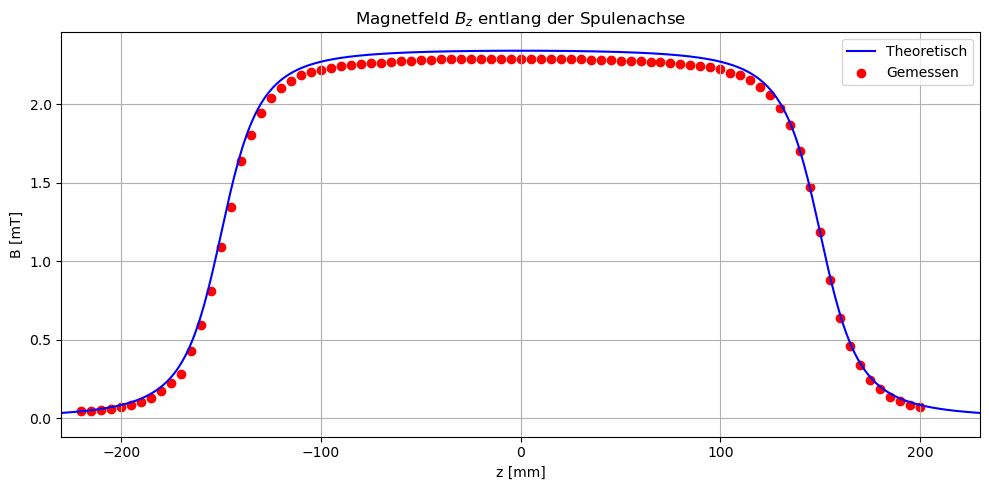

In [2]:
#| label: fig-magentfeldsolenoid
#| fig-cap: Das Magnetfeld des Solenoid 2 entlang der Spulenachse z
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Konstanten
mu0 = 4 * np.pi * 1e-7  # H/m

# Geometrie der Spule
L = 0.3  # Länge in m
N = 282  # Windungszahl
R = 0.0204  # Radius in m
I = 1.999  # Strom in Ampere

# Theoretisches Feld entlang z-Achse
def B_z(z, N, I, R, L):
    term1 = z / np.sqrt(R**2 + z**2)
    term2 = (L - z) / np.sqrt(R**2 + (L - z)**2)
    return (mu0 * N * I / (2 * L)) * (term1 + term2)

# z-Achse erzeugen (in m, aber später für Plot in mm)
z = np.linspace(-0.5, 0.5, 1000)
B_theoretical = B_z(z, N, I, R, L)

# Messdaten laden
df = pd.read_csv('./data/Solenoid.csv')  # Datei mit Spalten 'pos' (in mm) und 'by' (in mT)
B_measured = df['by'] * 10**(-3) # In mT unrechnen
z_measured = df['pos'] - 480 #Mitte von der Spule nach Experimentellen Daten


# Plot
plt.figure(figsize=(10, 5))
plt.plot((z - L/2) * 1000, B_theoretical * 1e3, label='Theoretisch', color='blue')  # z in mm, B in mT
plt.scatter(z_measured, B_measured, color='red', label='Gemessen', marker='o')
plt.title("Magnetfeld $B_z$ entlang der Spulenachse")
plt.xlabel("z [mm]")
plt.ylabel("B [mT]")
plt.legend()
plt.xlim(-230, 230)
plt.grid(True)
plt.tight_layout()
plt.show()

## Bestimmung der Induktivität
Die lokale magnetische Kopplung L(z)$ entlang der Spulenachse wurde sowohl theoretisch als auch experimentell bestimmt. Theoretisch wurde das axialsymmetrische Magnetfeld $B(z)$ eines langen Zylinderspulenmodells (Solenoid) berechnet. Daraus ergibt sich eine ortsabhängige Induktivität $L(z) ~ B(z)\cdot A$, wobei $A$ die Querschnittsfläche der Spule ist. Diese Größe beschreibt die lokale Kopplung an einen idealisierten, kleinen Sensor an Ort $z$.

Für jeden Messpunkt die entsprechende lokale Induktivität $L(z)=B(z)\cdot A/I$ bestimmt und gemeinsam mit den theoretischen Werten geplottet.
Wie in [Abbildung @fig-induktivitätsolenoid] zu sehen ist, stimmen die experimentellen Werte sehr gut mit den theoretischen Werten überein. Die Abweichung der experimentellen Werte von den theoretischen Werten kann durch die Messgenauigkeit des Sensors erklärt werden. Zudem kommen wir bei Induktivität am linken Spulenende auf $0.00075$ mH und am rechten auf einen Wert von $0.00078$ mH kommen.

Induktion am linken Spulenende: 0.00075 mH
Induktion am rechten Spulenende: 0.00078 mH


C:\Users\vd01p\AppData\Local\Temp\ipykernel_13260\2436268889.py:69: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


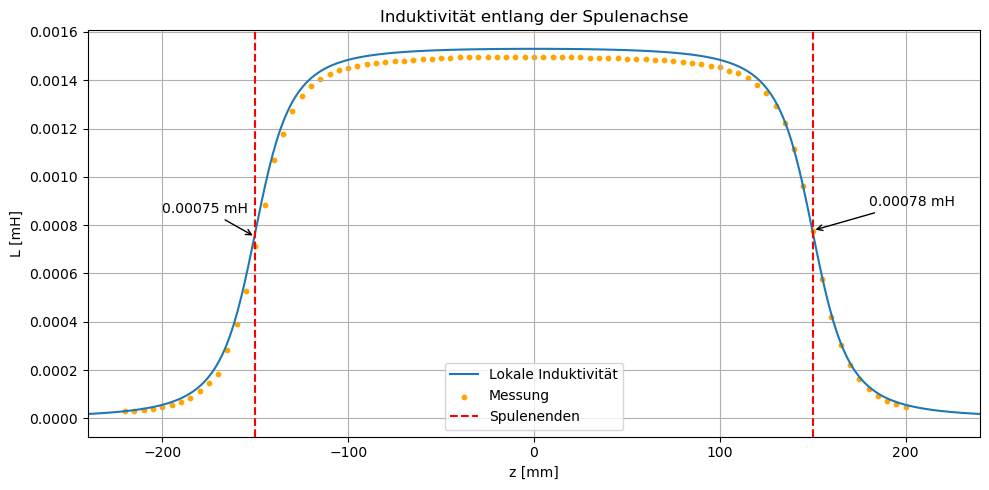

In [ ]:
#| label: fig-induktivitätsolenoid
#| fig-cap: Die Induktivität des Solenoid 2 entlang der Spulenachse z
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Konstanten
mu0 = 4 * np.pi * 1e-7  # H/m

# Geometrie der Spule
L = 0.3  # Länge in m
N = 282  # Windungszahl
R = 0.0204  # Radius in m
I = 1.999  # Strom in Ampere

# Fläche der Spule
A = np.pi * R**2  # m^2

# Magnetfeld B(z) entlang der Achse
def B_z(z, N, I, R, L):
    term1 = z / np.sqrt(R**2 + z**2)
    term2 = (L - z) / np.sqrt(R**2 + (L - z)**2)
    return (mu0 * N * I / (2 * L)) * (term1 + term2)

# z-Achse (Messpunkte), z=0 ist am Anfang der Spule
z = np.linspace(-0.5, 0.5, 1000)  # in m
B = B_z(z, N, I, R, L)

# Lokale "Induktivität" proportional zu B(z) * A
L_local = B * A / I  # in H (aber sehr klein)

# Messdaten laden
df = pd.read_csv('./data/Solenoid.csv')  # enthält Spalten 'pos' (in mm) und 'by' (in mT)

# Daten umrechnen
B_measured = df['by'] * 1e-3  # in T
z_measured = (df['pos'] - 480) * 1e-3  # in m, auf Spulenmitte bezogen

# Lokale "Induktivität" aus gemessenem Feld
L_local_measured = B_measured * A / I  # in mH

# Plot (relativ zur Spulenmitte: z - L/2)
plt.figure(figsize=(10, 5))
plt.plot((z - L/2) * 1000, L_local * 1000, label='Lokale Induktivität')
plt.scatter(z_measured * 1000, L_local_measured, label='Messung', color='orange', s=10)
plt.axvline(x=+150, color='red', linestyle='--', label='Spulenenden')
plt.axvline(x=-150, color='red', linestyle='--')  # Anfang

# Induktion an den Spulenenden berechnen
induktion_ende_links = L_local[np.abs((z - L/2) * 1000 + 150).argmin()] * 1000  # in mH
induktion_ende_rechts = L_local[np.abs((z - L/2) * 1000 - 150).argmin()] * 1000  # in mH

# Induktion an den Spulenenden anzeigen
print(f"Induktion am linken Spulenende: {induktion_ende_links:.5f} mH")
print(f"Induktion am rechten Spulenende: {induktion_ende_rechts:.5f} mH")

# Annotate the two points on the Spulenende
plt.annotate(f"{induktion_ende_links:.5f} mH", xy=(-150, induktion_ende_links), 
             xytext=(-200, induktion_ende_links + 0.0001), 
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

plt.annotate(f"{induktion_ende_rechts:.5f} mH", xy=(150, induktion_ende_rechts), 
             xytext=(180, induktion_ende_rechts + 0.0001), 
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

plt.title("Induktivität entlang der Spulenachse")
plt.xlabel("z [mm]")
plt.ylabel("L [mH]")
plt.legend()
plt.grid(True)
plt.xlim(-240, 240)
plt.tight_layout()
plt.show()

# Aufgabe 2: Magnetfeldverlauf flache Kreisspule
## Messung der axialen magnetischen Induktion B(z) einer flachen Kreisspule
Die Messung der flachen Kreisspule lief analog zu der Messung beim Solenoid. Nur das dieses mal der Sensor anstatt der Spule auf der Schiene geschoben wurde. In [Abbildung @fig-verscuhsaufbau-spule-3] zu sehen, ist der Aufbau auch fast identisch nur das eine andere, nich so lange, Spule genommen wurde.

![Versuchsaufbau für die messung der magentischen Induktion der flachen Kreisspule](./figures/Spule%203%20Aufbau.jpg){#fig-verscuhsaufbau-spule-3}

## Gemessene und theoretische Feldverteilung

4.99
7.5


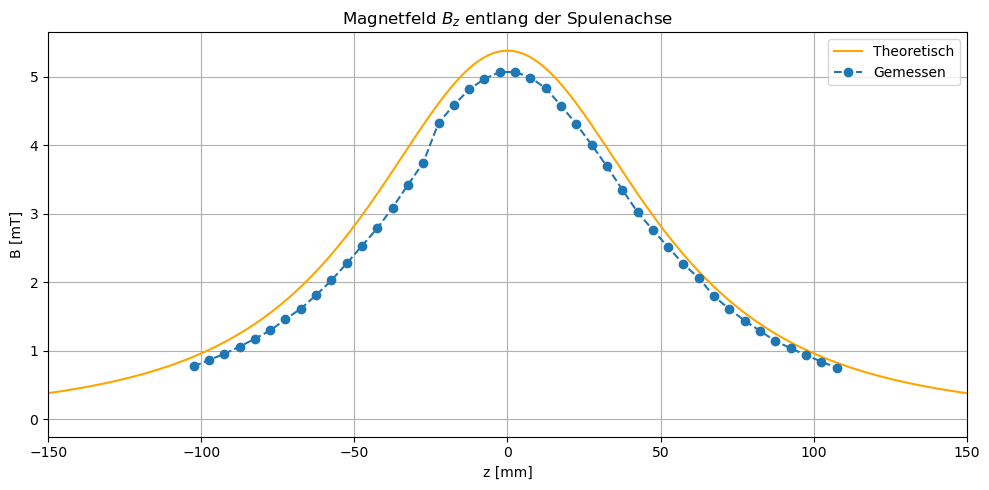

In [4]:
#| label: fig-magentfeldspule-3
#| fig-cap: Das Megnetfeld des Solenoid 2 entlang der Spulenachse z
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Konstanten
mu0 = 4 * np.pi * 1e-7  # H/m

# Geometrie der Spule
L = 0.01  # Länge in m
N = 320  # Windungszahl
R = 0.068  # Radius in m
I = 1.825  # Strom in Ampere

# Theoretisches Feld entlang z-Achse
def B_z(z, N, I, R, L):
    term1 = z / np.sqrt(R**2 + z**2)
    term2 = (L - z) / np.sqrt(R**2 + (L - z)**2)
    return (mu0 * N * I / (2 * L)) * (term1 + term2)

# z-Achse erzeugen (in m, aber später für Plot in mm)
z = np.linspace(-0.5, 0.5, 1000)
B_theoretical = B_z(z, N, I, R, L)

# Messdaten laden
df = pd.read_csv('./data/FlacheKreisspule3.csv')  # Datei mit Spalten 'pos' (in mm) und 'by' (in mT)
B_measured = df['by'] * 10**(-3) # In mT unrechnen
z_measured = df['pos'] - 372.5 #Mitte von der Spule nach Experimentellen Daten

# Das letzte Element von B_measured ausgeben
print(B_measured.iloc[-21])
print(z_measured.iloc[-21])

# Plot
plt.figure(figsize=(10, 5))
plt.plot((z - L/2) * 1000, B_theoretical * 1e3, label='Theoretisch', color='orange')  # z in mm, B in mT
plt.plot(z_measured, B_measured, "o--", label='Gemessen')
plt.title("Magnetfeld $B_z$ entlang der Spulenachse")
plt.xlabel("z [mm]")
plt.ylabel("B [mT]")
plt.xlim(-150, 150)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Ermittlung der position wo das Magnetfeld den Halbwert erreicht

Graphisch sieht man in [Abbildung @fig-magentfeldspule-3] gut, dass die Messdaten einen ungefähren maximalwert von $5$mT. Davon die Hälfte ist $2.5$mT was beim ablesen, bei einer ungefähren enfehrnung von $\pm50$mm von der Spulenmitte erreicht wird.
Beim ausrechnen wird mithilfe `np.max` der maximalwert des Datensatzes ermittelt und durch zwei geteilt. Dann werden die zwei Datenpunkte die am nächsten darunter und darüber sind aus dem Datensatz genommen und eine Gerade zwischen ihnen gezeichnet, wo dann der Abstand ermittelt werden kann.
Dabei kann wie in [Abbildung @fig-bz05-ermitteln] zu sehen ist, ein Halbwert des magentischen Feldes bei $-47.44$mm ermittelt werden, da die Spule als symmetrisch angenommen wird, kann gesagt werden, dass der Halbwert bei $\pm 47$mm von der Spulenmitte entfernt ist.


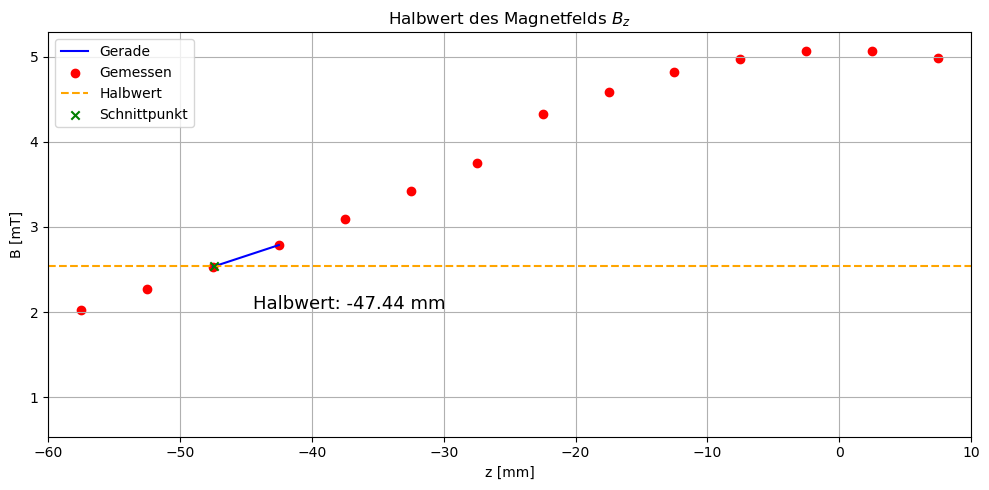

In [5]:
#| label: fig-bz05-ermitteln
#| fig-cap: Den Halbwert des Magnetfeldes relativ zur SPulenmitte ermitteln
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Messdaten laden
df = pd.read_csv('./data/FlacheKreisspule3.csv')  # Datei mit Spalten 'pos' (in mm) und 'by' (in mT)
B_measured = df['by'] * 10**(-3) # In mT unrechnen
z_measured = df['pos'] - 372.5 #Mitte von der Spule nach Experimentellen Daten

B_numpy = B_measured.to_numpy()
z_numpy = z_measured.to_numpy()

#Das Maximum bestimmen und durch 2 dividieren
half_value = np.max(B_numpy) / 2 #5.07

# Find the index where the array crosses the half value
index_half = np.where(B_numpy >= half_value)[0][0]

# Split the array into two parts: below and above the half value
B_numpy_below = B_numpy[:index_half + 1]
B_numpy_above = B_numpy[index_half:]
z_numpy_below = z_numpy[:index_half + 1]
z_numpy_above = z_numpy[index_half:]

# Get two points for a line for the below part
y1_below = B_numpy_below[-2]
x1_below = z_numpy_below[-2]
y2_below = B_numpy_below[-1]
x2_below = z_numpy_below[-1]

# Calculate the line equations
a_below = (y2_below - y1_below) / (x2_below - x1_below)
b_below = y2_below - a_below * x2_below
x_below = np.linspace(x1_below, x2_below, 100)
y_below = a_below * x_below + b_below

# Calculate the intersection point
intersection_x = (half_value - b_below) / a_below
intersection_y = half_value

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_below, y_below, label='Gerade', color='blue')  # Line below half value
plt.scatter(z_measured, B_measured, color='red', label='Gemessen', marker='o')
plt.axhline(half_value, color='orange', linestyle='--', label='Halbwert')
plt.scatter(intersection_x, intersection_y, color='green', label='Schnittpunkt', zorder=5, marker="x")  # Intersection marker
plt.annotate(f"Halbwert: {intersection_x:.2f} mm", xy=(intersection_x, intersection_y), 
             xytext=(intersection_x + 3, intersection_y - 0.5), 
             fontsize=13)
plt.title("Halbwert des Magnetfelds $B_z$")
plt.xlim(right=10, left=-60)
plt.xlabel("z [mm]")
plt.ylabel("B [mT]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()